In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing


In [2]:
df = pd.read_csv("Tahoe_Salt_example.csv", sep=";")
df.index = pd.period_range('1998Q2', '2001Q1', freq='Q')
df

,"Year, Qtr",Period t,Demand Dt
1998Q2,"1,2",1,8000
1998Q3,"1,3",2,13000
1998Q4,"1,4",3,23000
1999Q1,"2,1",4,34000
1999Q2,"2,2",5,10000
1999Q3,"2,3",6,18000
1999Q4,"2,4",7,23000
2000Q1,"3,1",8,38000
2000Q2,"3,2",9,12000
2000Q3,"3,3",10,13000


In [3]:
# deseaonalize demand
df['Seasonal'] = seasonal_decompose(df['Demand Dt'], model='additive', period=4).seasonal
df['Demand'] = seasonal_decompose(df['Demand Dt'], model='additive', period=4).trend

# linear regression with deseasonalized demand
reg_df = df[df['Demand'].notna()]
endog = np.array(reg_df['Demand'])
exog = sm.add_constant(np.array(reg_df['Period t']))
model = sm.OLS(endog, exog)
results = model.fit()
# print(results.summary())

initial_level = results.params[0]
initial_trend = results.params[1]
df['Demand'] = initial_level + initial_trend * np.array(list(range(1, 13)))
df['Seasonal Factor'] = df['Demand Dt'] / df['Demand']
print(df)
print(df.iloc[::4].mean())

initial_seasonal = []
for i in range(4):
    initial_seasonal.append(df.iloc[i::4].mean()['Seasonal Factor'])

print(initial_seasonal)


       Year, Qtr  Period t  Demand Dt  Seasonal        Demand  Seasonal Factor
1998Q2       1,2         1       8000 -10468.75  18962.797619         0.421879
1998Q3       1,3         2      13000  -6968.75  19486.607143         0.667125
1998Q4       1,4         3      23000   2343.75  20010.416667         1.149401
1999Q1       2,1         4      34000  15093.75  20534.226190         1.655772
1999Q2       2,2         5      10000 -10468.75  21058.035714         0.474878
1999Q3       2,3         6      18000  -6968.75  21581.845238         0.834034
1999Q4       2,4         7      23000   2343.75  22105.654762         1.040458
2000Q1       3,1         8      38000  15093.75  22629.464286         1.679227
2000Q2       3,2         9      12000 -10468.75  23153.273810         0.518285
2000Q3       3,3        10      13000  -6968.75  23677.083333         0.549054
2000Q4       3,4        11      32000   2343.75  24200.892857         1.322265
2001Q1       4,1        12      41000  15093.75  247

/var/folders/n4/xmqjmggd1s3drp4_ffnzq0400000gn/T/ipykernel_6794/1061562070.py:18: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  print(df.iloc[::4].mean())
/var/folders/n4/xmqjmggd1s3drp4_ffnzq0400000gn/T/ipykernel_6794/1061562070.py:22: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  initial_seasonal.append(df.iloc[i::4].mean()['Seasonal Factor'])


In [4]:
df['date'] = pd.PeriodIndex(df.index, freq='Q').to_timestamp()
df.index = list(df['date'])
df

,"Year, Qtr",Period t,Demand Dt,Seasonal,Demand,Seasonal Factor,date
1998-04-01,"1,2",1,8000,-10468.75,18962.797619,0.421879,1998-04-01
1998-07-01,"1,3",2,13000,-6968.75,19486.607143,0.667125,1998-07-01
1998-10-01,"1,4",3,23000,2343.75,20010.416667,1.149401,1998-10-01
1999-01-01,"2,1",4,34000,15093.75,20534.226190,1.655772,1999-01-01
1999-04-01,"2,2",5,10000,-10468.75,21058.035714,0.474878,1999-04-01
1999-07-01,"2,3",6,18000,-6968.75,21581.845238,0.834034,1999-07-01
1999-10-01,"2,4",7,23000,2343.75,22105.654762,1.040458,1999-10-01
2000-01-01,"3,1",8,38000,15093.75,22629.464286,1.679227,2000-01-01
2000-04-01,"3,2",9,12000,-10468.75,23153.273810,0.518285,2000-04-01
2000-07-01,"3,3",10,13000,-6968.75,23677.083333,0.549054,2000-07-01


<AxesSubplot:title={'center':'Quarterly Demand of Tahoe Salt'}>

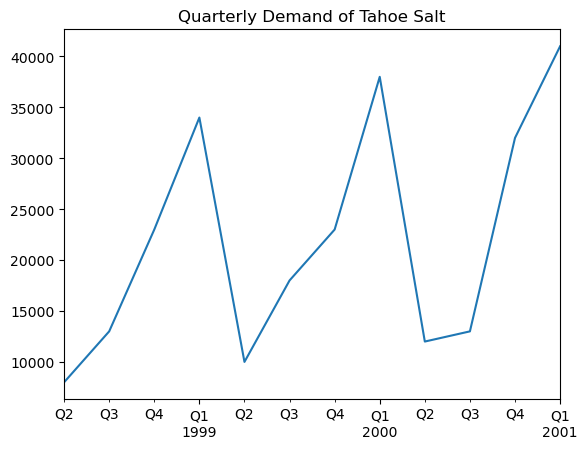

In [5]:
df["Demand Dt"].plot(title="Quarterly Demand of Tahoe Salt")

In [6]:
seasonal_periods = 4
alpha = 0.05
beta = 0.1
gamma = 0.1

winters_model = ExponentialSmoothing(
    df["Demand Dt"],
    trend="add",
    seasonal="mul",
    seasonal_periods=seasonal_periods,
    initialization_method="known",
    initial_level=initial_level,
    initial_trend=initial_trend,
    initial_seasonal=initial_seasonal
).fit(smoothing_level=alpha,
      smoothing_trend=beta,
      smoothing_seasonal=gamma,
      )

num_periods = 4
df["Forecast"] = winters_model.fittedvalues
forecast = pd.DataFrame(
    winters_model.forecast(num_periods),
    columns=["Forecast"]
)

df_forecast = df.append(forecast)
df_forecast

/Users/hgu/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/var/folders/n4/xmqjmggd1s3drp4_ffnzq0400000gn/T/ipykernel_6794/4286275003.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_forecast = df.append(forecast)


,"Year, Qtr",Period t,Demand Dt,Seasonal,Demand,Seasonal Factor,date,Forecast
1998-04-01,"1,2",1.0,8000.0,-10468.75,18962.797619,0.421879,1998-04-01,8949.284509
1998-07-01,"1,3",2.0,13000.0,-6968.75,19486.607143,0.667125,1998-07-01,13265.485842
1998-10-01,"1,4",3.0,23000.0,2343.75,20010.416667,1.149401,1998-10-01,23463.956804
1999-01-01,"2,1",4.0,34000.0,15093.75,20534.226190,1.655772,1999-01-01,33888.530759
1999-04-01,"2,2",5.0,10000.0,-10468.75,21058.035714,0.474878,1999-04-01,9745.890928
1999-07-01,"2,3",6.0,18000.0,-6968.75,21581.845238,0.834034,1999-07-01,14630.255873
1999-10-01,"2,4",7.0,23000.0,2343.75,22105.654762,1.040458,1999-10-01,26161.429856
2000-01-01,"3,1",8.0,38000.0,15093.75,22629.464286,1.679227,2000-01-01,37609.317201
2000-04-01,"3,2",9.0,12000.0,-10468.75,23153.273810,0.518285,2000-04-01,10825.279871
2000-07-01,"3,3",10.0,13000.0,-6968.75,23677.083333,0.549054,2000-07-01,16627.073509


<AxesSubplot:title={'center':"Winters' model for Tahoe Salt data"}>

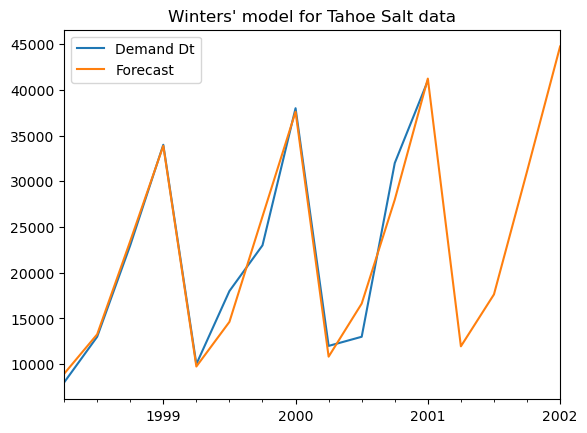

In [7]:
df_forecast[["Demand Dt","Forecast"]].plot(title="Winters' model for Tahoe Salt data")